# Pipeline 4 – Clustering

# 1. K-means Clustering Experiment
 – Unsupervised Learning  



## 本 notebook 覆盖内容

- **1.1 Brief Introduction of K-means**  
  K-means 的核心思想、算法步骤、常见参数、优缺点、适用场景。

- **1.2 K-means for clustering with visualization**  
  使用经典 **Iris 鸢尾花数据集**，通过 **PCA 降维到 2D** 后进行聚类可视化。  
  重点展示：
  - 每一轮迭代中的样本分配结果
  - 每一轮迭代中的聚类中心 center / centroid
  - 最终聚类结果与真实类别的对比

- **1.3 Explore K-means with different parameters**  
  探索不同参数对结果的影响：
  - 聚类数量 `K`
  - 最大迭代次数 `max_iter / iters`
  - 初始化方法 `init`
  - 使用 **DBI（Davies-Bouldin Index）** 评估聚类效果

---


## 学习建议

请不要只按顺序运行代码。更好的学习方式是：

1. 先读文字解释。
2. 再运行代码。
3. 看输出图像。
4. 修改参数，例如 `K=2 / 3 / 4 / 5`，观察结果如何变化。
5. 最后回答 notebook 末尾的思考题。

## 🌱 课前准备

建议在 Jupyter Notebook / JupyterLab / VSCode Notebook 中运行。

### 安装方式

如果你的环境没有这些库，可以先运行下面命令：

```bash
pip install numpy pandas matplotlib scikit-learn jupyter
```

或者使用 conda：

```bash
conda create -n kmeans_lab python=3.10
conda activate kmeans_lab
pip install numpy pandas matplotlib scikit-learn jupyter
```

---

## 课程目标


- 什么是无监督学习
- 什么是聚类
- K-means 为什么叫 K-means
- center / centroid 是什么
- 每一轮迭代发生了什么
- 为什么需要 PCA 画二维图
- K 和迭代次数怎么影响结果
- DBI 指标如何理解

In [2]:
# 检查运行环境
# 为了避免某些电脑上数学库多线程过度占用资源，先限制线程数。
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

# 这一步不是必须的，但教学时很有用：可以确认学生使用的 Python 和 scikit-learn 版本。

import sys
import platform
import sklearn

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("Platform         :", platform.platform())
print("scikit-learn     :", sklearn.__version__)

Python executable: /opt/anaconda3/envs/ann/bin/python
Python version   : 3.9.23
Platform         : macOS-15.6-arm64-arm-64bit
scikit-learn     : 1.6.1


## 📖 1.1 K-means 简介（main idea & parameters）

### 1. 什么是聚类？

聚类（Clustering）是一种**无监督学习（Unsupervised Learning）**任务。

监督学习和无监督学习的区别：

| 类型 | 数据里有没有标签？ | 目标 |
|---|---:|---|
| 监督学习 | 有标签，例如花的种类、房价、是否患病 | 学习输入和标签之间的关系 |
| 无监督学习 | 没有标签，只有样本特征 | 自动发现数据内部结构 |

K-means 是最经典的聚类算法之一。

它要解决的问题是：

> 给定一堆没有标签的数据点，自动把它们分成 K 个组，使得同一组内部尽量相似，不同组之间尽量不同。

---

### 2. K-means 这个名字是什么意思？

- `K`：表示你希望分成几个簇（cluster）。
- `means`：表示每个簇用这个簇内样本的**均值点**作为中心。

所以 K-means 可以理解为：

> 找到 K 个中心点，并让每个数据点归属于距离自己最近的中心点。

---

### 3. K-means 的核心思想

K-means 会重复做两件事：

#### Step 1：分配样本

对每一个样本点，计算它到所有中心点的距离，然后把它分到最近的中心点所在的簇。

#### Step 2：更新中心

每个簇拿到自己的样本后，重新计算这些样本的平均位置，把这个平均位置作为新的中心。

然后继续重复 Step 1 和 Step 2，直到：

- 中心点几乎不再移动，或者
- 达到最大迭代次数 `max_iter`。

---

### 4. K-means 想优化什么？

K-means 的目标是让每个样本点离自己簇中心尽可能近。

常见目标函数是 **SSE / Inertia**：

\[
J = \sum_{i=1}^{n} \left\|x_i - c_{z_i}\right\|^2
\]

其中：

- \(x_i\)：第 i 个样本
- \(z_i\)：第 i 个样本所属的簇编号
- \(c_{z_i}\)：该簇的中心点
- \(\|x_i - c_{z_i}\|^2\)：样本到所属中心的平方距离

通俗理解：

> Inertia 越小，说明样本离自己的中心越近，簇内部越紧凑。

## K-means 的常见参数

下面这些参数是做实验时最常见的。

### `n_clusters` / `K`

要分成几个簇。

例如：

```python
KMeans(n_clusters=3)
```

在 Iris 数据集中真实类别有 3 类，所以我们通常先尝试 `K=3`。  
但在真实无标签任务中，我们通常不知道 K，需要用指标或业务知识来选择。

---

### `init`

初始化中心点的方法。

常见选择：

- `'random'`：随机选中心点，简单但不稳定。
- `'k-means++'`：更聪明的初始化方法，通常效果更稳定，是 scikit-learn 默认推荐方法。

---

### `max_iter` / `iters`

最大迭代次数。

如果设置得太小，算法可能还没收敛就停止。  
如果设置得较大，结果通常更稳定，但运行时间可能略微增加。

---

### `n_init`

K-means 因为初始化随机，可能陷入不同的局部最优。  
`n_init` 表示重复运行几次 K-means，然后选择效果最好的一次。

教学建议：

- 初学时先用 `n_init=1` 观察随机初始化影响。
- 实际使用时常用 `n_init=10` 或更多。

---

### `random_state`

随机种子。

为了让每次运行结果一致，教学和实验报告里建议固定 `random_state`。

---

## K-means 的优缺点

### 优点

- 思想简单，容易理解。
- 运行速度快。
- 适合球状、凸形、边界比较清晰的簇。
- 在大数据集上也常用。

### 缺点

- 需要提前指定 K。
- 对初始中心敏感。
- 对异常值敏感。
- 不适合非球形簇，例如月牙形、环形数据。
- 不直接适合类别型特征。

---

## 本实验的核心问题

本实验会围绕 3 个问题展开：

1. K-means 每一轮到底在做什么？
2. 在 Iris 数据上，K-means 能不能自动发现花的类别结构？
3. 参数 K 和迭代次数如何影响聚类效果？

## 🧰 导入库与全局设置

下面导入本实验需要使用的库。

注意：K-means 依赖距离计算，所以**特征尺度非常重要**。  
如果一个特征范围特别大，它会在距离计算中占主导。  
因此 K-means 前通常需要做标准化 `StandardScaler`。

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score, silhouette_score
from threadpoolctl import threadpool_limits

# 为了让图像在 notebook 中显示得更清楚
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# 固定随机种子，保证每次运行结果一致
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!



# 🌟 0 基础图解：K-means 到底在做什么？

在正式进入 Iris 数据集之前，我们先用一个**非常生活化、非常直观**的小例子理解 K-means。

## 例子：给学生自动分学习小组

假设班里有很多学生，老师想根据两个维度给学生分组：

- 横坐标：数学成绩
- 纵坐标：英语成绩

每个学生就可以看成平面上的一个点。

如果老师想把学生分成 3 个学习小组，那么 K-means 中的：

| K-means 术语 | 生活里的意思 |
|---|---|
| 数据点 data point | 一个学生 |
| 特征 feature | 数学成绩、英语成绩 |
| K | 想分成几个组 |
| 簇 cluster | 一个学习小组 |
| 聚类中心 centroid | 每个小组的“代表位置” |
| 距离 distance | 学生和小组中心之间的远近 |
| 迭代 iteration | 重新分组、重新计算中心的一轮过程 |

K-means 的核心想法可以先记成一句话：

> **先随便放几个中心，让每个点找最近的中心；再把中心移动到本组点的平均位置；不断重复，直到分组稳定。**



## 第 0 步：先看一堆“还没有分组”的点

下面我们先生成一批二维数据点。

你可以把它们理解成一群学生：

- 每个点 = 一个学生
- 横坐标 = 特征 1，例如数学成绩
- 纵坐标 = 特征 2，例如英语成绩

此时我们**还没有告诉算法每个点属于哪一类**，这就是无监督学习的典型场景。


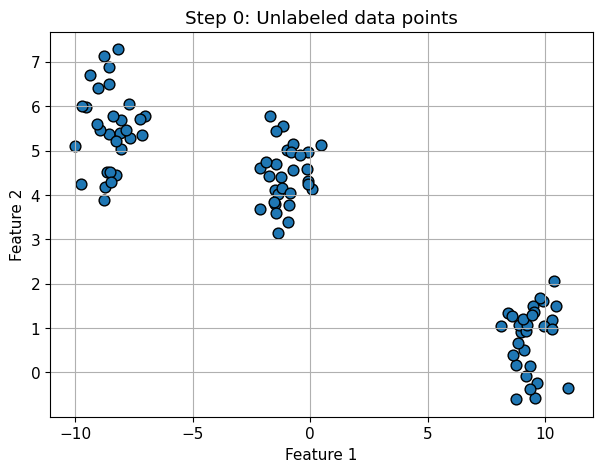

In [4]:

# =========================================================
# 0基础图解：先生成一批二维点
# =========================================================
# make_blobs 会生成几个比较明显的“团状数据”
# 注意：这里的 y_zero_true 只是为了生成数据方便，后面 K-means 不会使用它。
# 在真实的无监督学习中，我们通常不知道真实标签。
X_zero, y_zero_true = make_blobs(
    n_samples=90,        # 一共生成 90 个点，可以理解为 90 个学生
    centers=3,           # 数据背后大致有 3 个团
    cluster_std=0.75,    # 每个团的分散程度，越大越分散
    random_state=7
)

plt.figure(figsize=(7, 5))
plt.scatter(X_zero[:, 0], X_zero[:, 1], s=60, edgecolor="black")
plt.title("Step 0: Unlabeled data points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()



## 第 1 步：先放 K 个“临时中心”

现在我们假设要分成 3 组，所以：

```python
K = 3
```

K-means 会先找 3 个临时中心。

为了教学更清楚，下面我们手动指定 3 个初始中心。真实使用 `sklearn.KMeans` 时，算法会自动初始化中心。

你可以把这 3 个中心想象成操场上的 3 个集合点：学生会先去离自己最近的集合点。


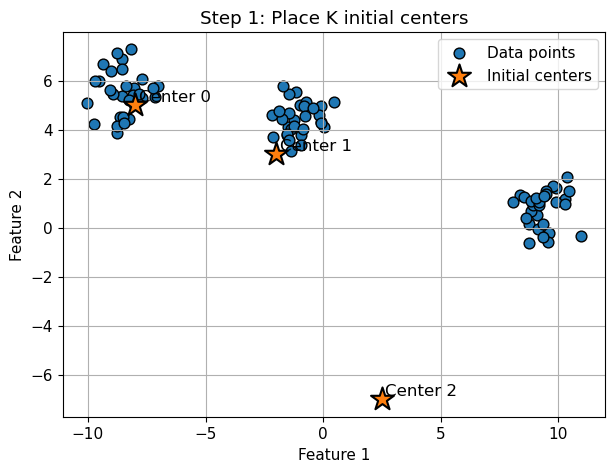

In [5]:

# =========================================================
# 第 1 步：手动指定 3 个初始中心
# =========================================================
K_zero = 3

# 为了让图像更容易看懂，这里手动放 3 个初始中心
# 每一行是一个中心点：[横坐标, 纵坐标]
centers_zero = np.array([
    [-8.0,  5.0],
    [-2.0,  3.0],
    [ 2.5, -7.0]
])

plt.figure(figsize=(7, 5))
plt.scatter(X_zero[:, 0], X_zero[:, 1], s=60, edgecolor="black", label="Data points")
plt.scatter(
    centers_zero[:, 0], centers_zero[:, 1],
    s=300, marker="*", edgecolor="black", linewidth=1.5,
    label="Initial centers"
)

# 给每个中心标上编号，方便学生理解
for i, c in enumerate(centers_zero):
    plt.text(c[0] + 0.15, c[1] + 0.15, f"Center {i}", fontsize=12)

plt.title("Step 1: Place K initial centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()



## 第 2 步：每个点找离自己最近的中心

K-means 的第一件重要事情就是：

> 对每一个点，计算它到所有中心的距离，然后把它分给最近的中心。

这里最常用的是**欧氏距离**，也就是平面上两点之间的直线距离。

比如一个点离 Center 0 最近，它就暂时属于第 0 组。

这一步叫做：**assignment step，分配步骤**。


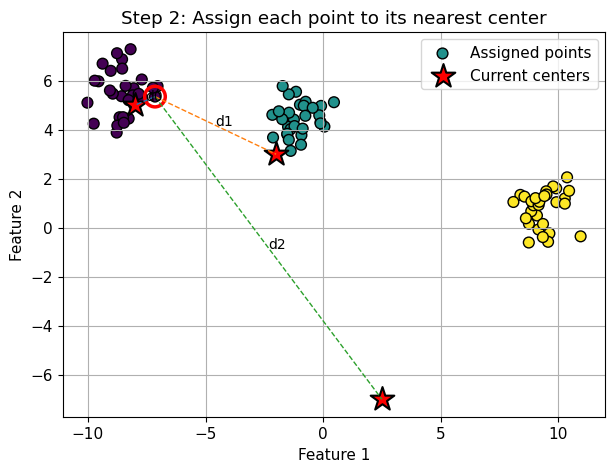

被红圈标出的这个点到 3 个中心的距离分别是：
到 Center 0 的距离: 0.92
到 Center 1 的距离: 5.66
到 Center 2 的距离: 15.67
所以它被分配给 Center 0 所在的组。


In [6]:

# =========================================================
# 第 2 步：计算每个点到每个中心的距离，并分配给最近中心
# =========================================================
# X_zero 的形状是 (90, 2)，表示 90 个点，每个点 2 个特征
# centers_zero 的形状是 (3, 2)，表示 3 个中心，每个中心 2 个坐标

# 下面这一行利用 numpy 广播机制：
# X_zero[:, np.newaxis, :] 会把数据形状变成 (90, 1, 2)
# centers_zero[np.newaxis, :, :] 会把中心形状变成 (1, 3, 2)
# 相减后得到 (90, 3, 2)：每个点到每个中心在两个坐标上的差
# np.linalg.norm(..., axis=2) 会计算二维距离，得到 (90, 3)
distances_zero = np.linalg.norm(
    X_zero[:, np.newaxis, :] - centers_zero[np.newaxis, :, :],
    axis=2
)

# 对每个点，找到距离最小的中心编号
labels_zero = np.argmin(distances_zero, axis=1)

plt.figure(figsize=(7, 5))
plt.scatter(
    X_zero[:, 0], X_zero[:, 1],
    c=labels_zero, cmap="viridis", s=60, edgecolor="black",
    label="Assigned points"
)
plt.scatter(
    centers_zero[:, 0], centers_zero[:, 1],
    s=320, marker="*", c="red", edgecolor="black", linewidth=1.5,
    label="Current centers"
)

# 选一个点出来，画出它到三个中心的连线，帮助理解“距离”
sample_id = 10
sample_point = X_zero[sample_id]
plt.scatter(sample_point[0], sample_point[1], s=220, facecolor="none", edgecolor="red", linewidth=2.5)
for j, center in enumerate(centers_zero):
    plt.plot(
        [sample_point[0], center[0]],
        [sample_point[1], center[1]],
        linestyle="--", linewidth=1
    )
    mid_x = (sample_point[0] + center[0]) / 2
    mid_y = (sample_point[1] + center[1]) / 2
    plt.text(mid_x, mid_y, f"d{j}", fontsize=10)

plt.title("Step 2: Assign each point to its nearest center")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("被红圈标出的这个点到 3 个中心的距离分别是：")
for j, d in enumerate(distances_zero[sample_id]):
    print(f"到 Center {j} 的距离: {d:.2f}")
print(f"所以它被分配给 Center {labels_zero[sample_id]} 所在的组。")



## 第 3 步：重新计算每一组的中心

分完组之后，原来的中心可能并不在本组点的中间位置。

所以 K-means 会做第二件重要事情：

> 对每一组，计算这一组所有点的平均位置，把中心移动过去。

这一步叫做：**update step，更新中心步骤**。

如果把一个簇看成一个学习小组，那么新的中心就是这个组学生的“平均水平”。


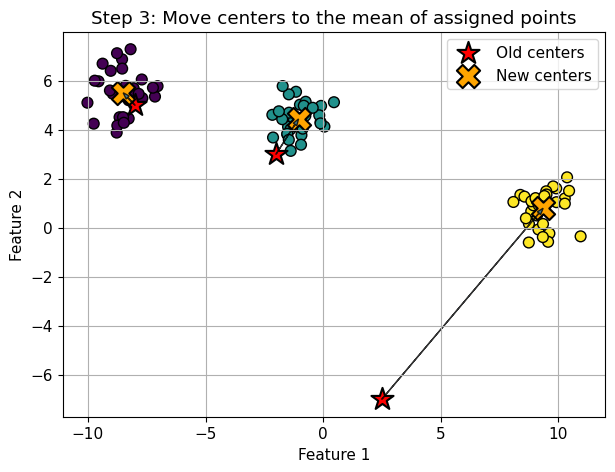

旧中心位置：
[[-8.   5. ]
 [-2.   3. ]
 [ 2.5 -7. ]]

更新后的新中心位置：
[[-8.5   5.51]
 [-1.04  4.44]
 [ 9.36  0.79]]


In [7]:

# =========================================================
# 第 3 步：把中心移动到本组点的平均位置
# =========================================================
new_centers_zero = np.zeros_like(centers_zero)

for k in range(K_zero):
    # 取出第 k 组的所有点
    points_in_cluster = X_zero[labels_zero == k]
    
    # 如果这个组里有点，就计算平均值作为新中心
    if len(points_in_cluster) > 0:
        new_centers_zero[k] = points_in_cluster.mean(axis=0)
    else:
        # 极少数情况下某个中心没有分到点，教学中先保留原中心
        new_centers_zero[k] = centers_zero[k]

plt.figure(figsize=(7, 5))
plt.scatter(
    X_zero[:, 0], X_zero[:, 1],
    c=labels_zero, cmap="viridis", s=60, edgecolor="black"
)
plt.scatter(
    centers_zero[:, 0], centers_zero[:, 1],
    s=280, marker="*", c="red", edgecolor="black", linewidth=1.5,
    label="Old centers"
)
plt.scatter(
    new_centers_zero[:, 0], new_centers_zero[:, 1],
    s=280, marker="X", c="orange", edgecolor="black", linewidth=1.5,
    label="New centers"
)

# 用箭头表示中心移动方向
for old_c, new_c in zip(centers_zero, new_centers_zero):
    plt.arrow(
        old_c[0], old_c[1],
        new_c[0] - old_c[0], new_c[1] - old_c[1],
        length_includes_head=True, head_width=0.18, alpha=0.8
    )

plt.title("Step 3: Move centers to the mean of assigned points")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("旧中心位置：")
print(np.round(centers_zero, 2))
print("\n更新后的新中心位置：")
print(np.round(new_centers_zero, 2))



## 第 4 步：重复“分配点 → 更新中心”，直到稳定

K-means 不是只做一次分组，而是不断重复：

1. **分配点**：每个点找最近的中心
2. **更新中心**：每组中心移动到本组点的平均位置
3. 再分配、再更新、再分配、再更新……

直到中心几乎不动，或者达到最大迭代次数。

这就是 K-means 的完整流程。


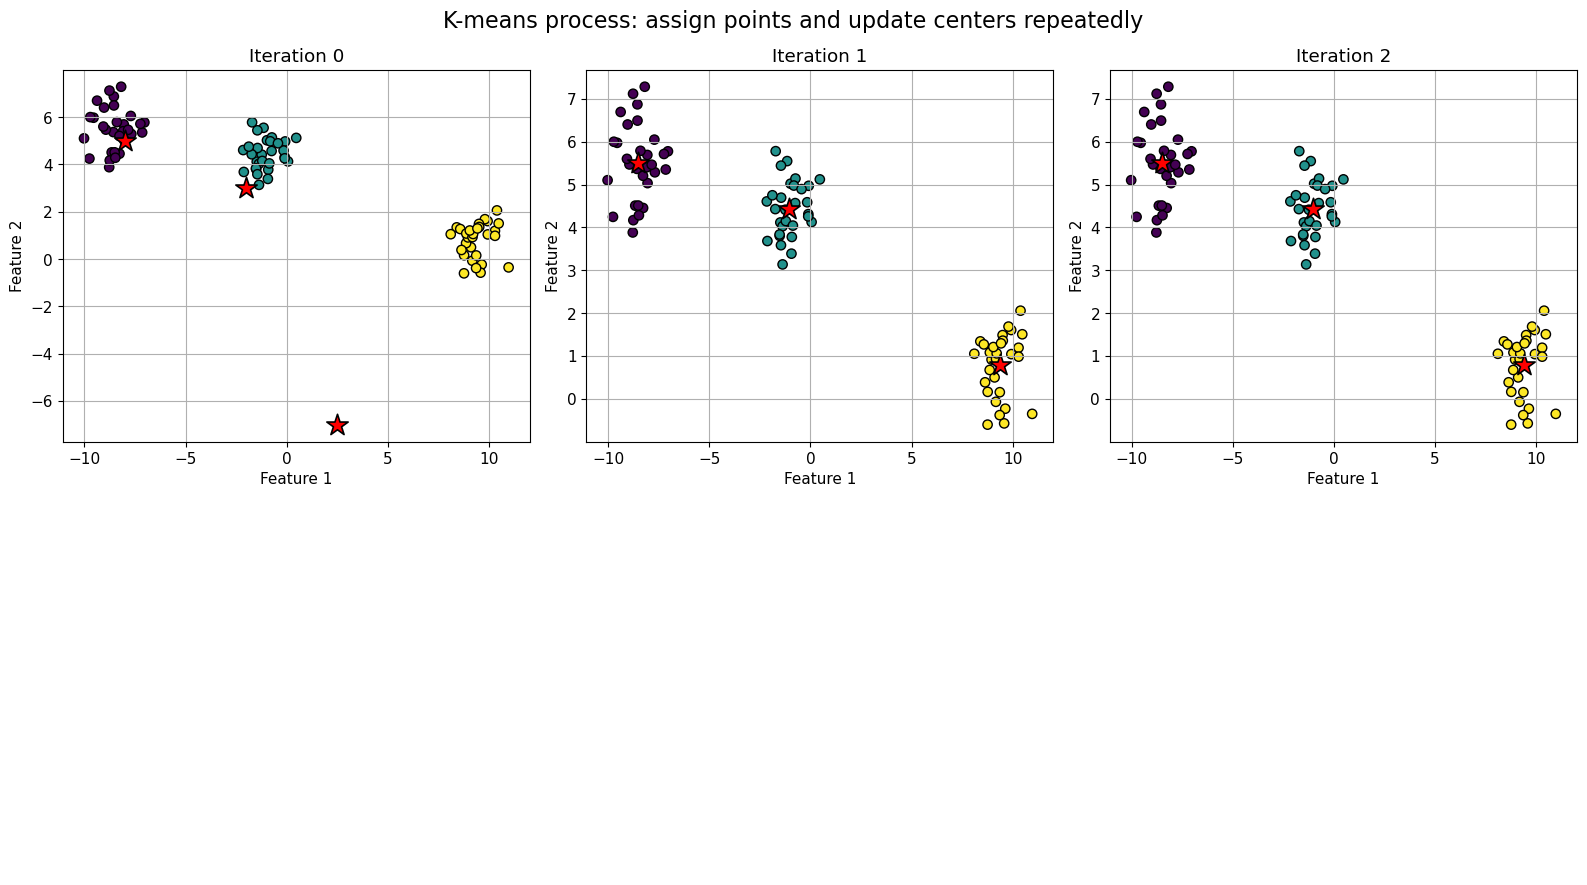

In [8]:

# =========================================================
# 第 4 步：把 K-means 的多轮迭代画出来
# =========================================================
# 这个函数只用于教学演示：
# 它会保存每一轮的 labels 和 centers，方便我们画图观察算法过程。
def run_kmeans_for_teaching(X, initial_centers, max_iter=5):
    centers = initial_centers.copy()
    history = []
    
    for it in range(max_iter):
        # 1. 计算距离
        distances = np.linalg.norm(
            X[:, np.newaxis, :] - centers[np.newaxis, :, :],
            axis=2
        )
        
        # 2. 分配到最近中心
        labels = np.argmin(distances, axis=1)
        
        # 保存当前轮结果，用于画图
        history.append((centers.copy(), labels.copy()))
        
        # 3. 更新中心
        new_centers = centers.copy()
        for k in range(len(centers)):
            if np.any(labels == k):
                new_centers[k] = X[labels == k].mean(axis=0)
        
        # 4. 如果中心几乎不变，就可以提前停止
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    
    # 最后再保存一次最终状态
    distances = np.linalg.norm(
        X[:, np.newaxis, :] - centers[np.newaxis, :, :],
        axis=2
    )
    labels = np.argmin(distances, axis=1)
    history.append((centers.copy(), labels.copy()))
    return history

history_zero = run_kmeans_for_teaching(X_zero, centers_zero, max_iter=6)

# 为了让学生更容易对比，这里把前 6 个状态放在一张大图中
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax_id, ax in enumerate(axes):
    if ax_id < len(history_zero):
        centers_now, labels_now = history_zero[ax_id]
        ax.scatter(
            X_zero[:, 0], X_zero[:, 1],
            c=labels_now, cmap="viridis", s=45, edgecolor="black"
        )
        ax.scatter(
            centers_now[:, 0], centers_now[:, 1],
            s=260, marker="*", c="red", edgecolor="black", linewidth=1.2
        )
        ax.set_title(f"Iteration {ax_id}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
    else:
        ax.axis("off")

plt.suptitle("K-means process: assign points and update centers repeatedly", fontsize=16)
plt.tight_layout()
plt.show()



## 现在你应该理解的核心点

学到这里，不需要先背复杂公式，只需要先理解这 5 件事：

1. **K 是想分成几个组**，例如 K=3 就是分成 3 类。
2. **中心点代表每个组的位置**，可以理解为每组的“平均代表”。
3. **每个点会被分给最近的中心**，所以距离计算很重要。
4. **中心会不断更新**，更新到本组点的平均位置。
5. **K-means 是迭代算法**，它会重复“分配 → 更新”，直到结果稳定。

接下来我们再进入正式实验：

- 用自己生成的二维数据进一步观察 K-means；
- 用 Iris 鸢尾花数据集做真实聚类；
- 用 PCA 把高维数据压缩成二维图像；
- 用 DBI 指标比较不同参数效果。


## 🧪 先用一个简单二维数据理解 K-means

在进入 Iris 数据集之前，我们先自己造一个简单的二维数据集。

原因：

- 二维数据可以直接画图。
- 学生更容易看到“点如何被分组”。
- 后面再进入真实数据集时，理解会更自然。

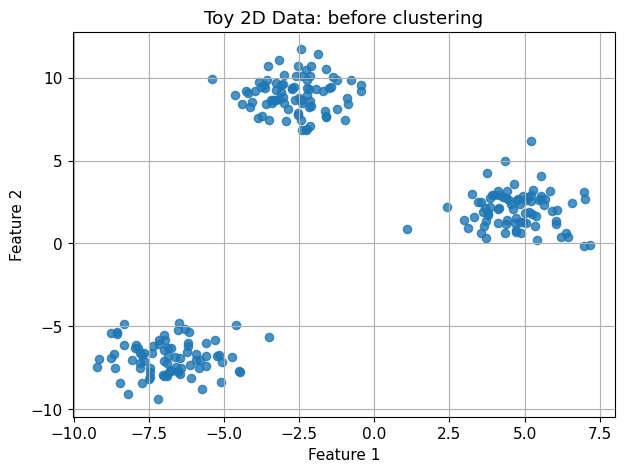

Data shape: (240, 2)
每一行是一个样本，每一列是一个特征。这里共有 240 个样本，每个样本有 2 个特征。


In [9]:
# make_blobs 可以生成几个比较清晰的“团状”数据
# centers=3 表示生成 3 个真实团块
X_toy, y_toy_true = make_blobs(
    n_samples=240,
    centers=3,
    cluster_std=1.1,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(7, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], s=35, alpha=0.8)
plt.title("Toy 2D Data: before clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

print("Data shape:", X_toy.shape)
print("每一行是一个样本，每一列是一个特征。这里共有 240 个样本，每个样本有 2 个特征。")

## 手写一个简化版 K-means：看懂每一步

虽然实际项目中我们通常直接使用 `sklearn.cluster.KMeans`，但为了教学，我们先手写一个简化版本。

手写版本的好处是：

- 可以保存每一轮迭代结果。
- 可以画出每一轮中心点如何移动。
- 可以真正理解 K-means，而不是只会调用 API。

---

## K-means 伪代码

```text
输入：数据 X，聚类数量 K，最大迭代次数 max_iter

1. 随机选择 K 个样本作为初始中心
2. 重复以下过程：
   a. 对每个样本，计算它到 K 个中心的距离
   b. 把样本分配给最近的中心
   c. 对每个簇，计算簇内样本均值，作为新中心
   d. 如果中心几乎不再变化，停止
3. 输出：每个样本所属簇，以及最终中心点
```

In [10]:
def euclidean_distance_matrix(X, centers):
    """
    计算每个样本到每个中心的欧氏距离。

    参数：
    X       : shape = (n_samples, n_features)
              数据矩阵，每一行是一个样本。
    centers : shape = (K, n_features)
              K 个聚类中心。

    返回：
    distances : shape = (n_samples, K)
                第 i 行第 j 列表示第 i 个样本到第 j 个中心的距离。
    """
    # X[:, np.newaxis, :] 的形状会变成 (n_samples, 1, n_features)
    # centers[np.newaxis, :, :] 的形状会变成 (1, K, n_features)
    # 二者相减后，NumPy 会自动广播成 (n_samples, K, n_features)
    return np.linalg.norm(X[:, np.newaxis, :] - centers[np.newaxis, :, :], axis=2)


def assign_clusters(X, centers):
    """
    根据距离最近原则，为每个样本分配簇标签。
    """
    distances = euclidean_distance_matrix(X, centers)
    labels = np.argmin(distances, axis=1)
    return labels


def update_centers(X, labels, K, old_centers):
    """
    根据当前标签，重新计算每个簇的中心。
    如果某个簇没有样本，保留原来的中心，避免报错。
    """
    new_centers = []
    for k in range(K):
        points_in_cluster = X[labels == k]
        if len(points_in_cluster) == 0:
            # 空簇：这个簇没有任何样本。
            # 简化处理：保留原中心。
            new_centers.append(old_centers[k])
        else:
            # 计算簇内样本的平均值，作为新中心。
            new_centers.append(points_in_cluster.mean(axis=0))
    return np.vstack(new_centers)


def kmeans_manual(X, K=3, max_iter=10, random_state=42, tolerance=1e-4):
    """
    一个教学用的手写 K-means。

    返回：
    labels  : 最终每个样本的簇标签
    centers : 最终中心点
    history : 每一轮的标签和中心，方便可视化
    """
    rng = np.random.default_rng(random_state)

    # 随机选择 K 个样本作为初始中心。
    initial_indices = rng.choice(len(X), size=K, replace=False)
    centers = X[initial_indices].copy()

    history = []

    for iteration in range(max_iter):
        # Step 1：根据最近中心分配样本
        labels = assign_clusters(X, centers)

        # 保存当前状态，用于画图
        history.append({
            "iteration": iteration,
            "labels": labels.copy(),
            "centers": centers.copy()
        })

        # Step 2：根据当前簇重新计算中心
        new_centers = update_centers(X, labels, K, centers)

        # 判断中心点移动距离是否足够小
        center_shift = np.linalg.norm(new_centers - centers)
        centers = new_centers

        if center_shift < tolerance:
            # 再保存一次收敛后的中心，方便观察最终结果
            labels = assign_clusters(X, centers)
            history.append({
                "iteration": iteration + 1,
                "labels": labels.copy(),
                "centers": centers.copy()
            })
            break

    return labels, centers, history

print("Manual K-means helper functions are ready!")

Manual K-means helper functions are ready!


In [11]:
# 在简单二维数据上运行手写 K-means
labels_toy, centers_toy, history_toy = kmeans_manual(
    X_toy,
    K=3,
    max_iter=8,
    random_state=3
)

print("Number of saved iterations:", len(history_toy))
print("Final centers:")
print(np.round(centers_toy, 3))

Number of saved iterations: 4
Final centers:
[[-2.649  8.998]
 [-6.85  -6.913]
 [ 4.737  2.053]]


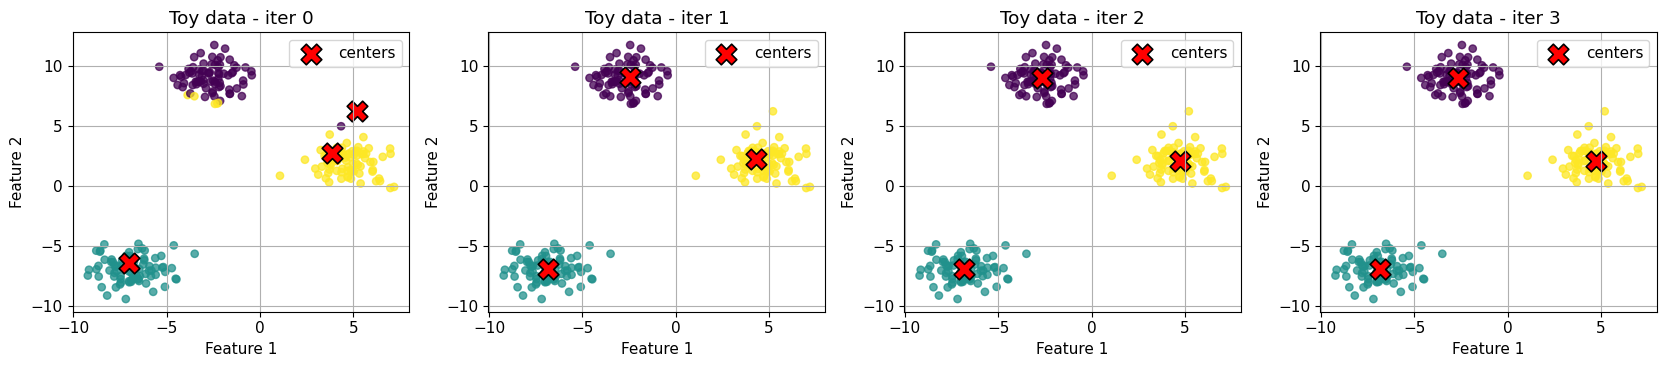

In [12]:
def plot_kmeans_history(X, history, title_prefix="K-means iteration"):
    """
    把 K-means 每一轮的分配结果和中心点画出来。
    """
    n_steps = len(history)
    n_cols = min(4, n_steps)
    n_rows = int(np.ceil(n_steps / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.8 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax, state in zip(axes, history):
        labels = state["labels"]
        centers = state["centers"]
        iteration = state["iteration"]

        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=28, alpha=0.75)
        ax.scatter(
            centers[:, 0], centers[:, 1],
            c="red", marker="X", s=220,
            edgecolor="black", linewidth=1.2,
            label="centers"
        )
        ax.set_title(f"{title_prefix} {iteration}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend(loc="best")

    # 如果子图数量多于实际迭代数量，把多余子图隐藏
    for ax in axes[len(history):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plot_kmeans_history(X_toy, history_toy, title_prefix="Toy data - iter")

## 从上面的图中应该观察什么？

请重点观察红色 `X` 标记的中心点：

1. 初始中心通常不是最优位置。
2. 每一轮分配样本后，中心会移动到每个簇的平均位置。
3. 随着迭代进行，中心移动越来越小。
4. 最后中心几乎稳定，算法停止。

这就是 K-means 的核心：

> 分配样本 → 更新中心 → 再分配 → 再更新 → 直到稳定。

---

## 一个很重要的提醒

K-means 的簇编号没有语义。

例如：

- 第 0 簇不一定代表“第一类花”
- 第 1 簇也不一定代表“第二类花”

聚类标签只是算法自动给的编号。  
在无监督学习中，算法并不知道真实类别名称。

# 📖 1.2 K-means for clustering with visualization（Iris + PCA）

## 为什么使用 Iris 数据集？

Iris（鸢尾花）是机器学习入门里最经典的数据集之一。

它包含 150 个样本，每个样本是一朵鸢尾花。  
每朵花有 4 个特征：

1. sepal length：萼片长度
2. sepal width：萼片宽度
3. petal length：花瓣长度
4. petal width：花瓣宽度

真实类别有 3 类：

- setosa
- versicolor
- virginica

---

## 重要说明：聚类任务一般不使用标签训练

根据数据点之间的距离，把彼此更接近、更相似的数据分到同一类。

虽然 Iris 数据集中有真实标签，但 K-means 是无监督学习。  
所以训练 K-means 时，我们只使用特征 `X`，不使用真实标签 `y`。

真实标签只在最后用于：

- 帮助我们理解聚类结果
- 做对比可视化
- 计算一些外部评估指标，例如 ARI

In [13]:
# 读取 Iris 数据集
iris = load_iris(as_frame=True)

X_iris = iris.data.copy()
y_iris = iris.target.copy()

print("Feature names:")
print(list(X_iris.columns))

print("\nClass names:")
print(list(iris.target_names))

print("\nData shape:", X_iris.shape)

print("\nFirst 5 rows:")
display(X_iris.head())

print("\nLabel distribution:")
display(y_iris.value_counts().sort_index().rename(index=dict(enumerate(iris.target_names))))

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Class names:
['setosa', 'versicolor', 'virginica']

Data shape: (150, 4)

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Label distribution:


target
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 为什么 K-means 前要标准化？

K-means 根据距离判断样本是否相似。  
如果一个特征的数值范围很大，它会在距离计算中占更大权重。

例如：

| 特征 | 范围 |
|---|---:|
| 身高 cm | 150 到 190 |
| 年龄 | 10 到 80 |
| 收入 | 3000 到 100000 |

如果直接算距离，收入会远远压过身高和年龄。

所以我们通常先使用 `StandardScaler`，把每个特征变成：

- 均值约为 0
- 标准差约为 1

这样不同特征更公平。

In [14]:
# 标准化：让每个特征的尺度更接近
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

# 转回 DataFrame，方便展示
X_scaled_df = pd.DataFrame(X_scaled, columns=X_iris.columns)

print("标准化后的前 5 行：")
display(X_scaled_df.head())

print("\n标准化后每个特征的均值（应接近 0）：")
display(X_scaled_df.mean().round(6))

print("\n标准化后每个特征的标准差（应接近 1 左右）：")
display(X_scaled_df.std().round(6))

标准化后的前 5 行：


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444



标准化后每个特征的均值（应接近 0）：


sepal length (cm)   -0.0
sepal width (cm)    -0.0
petal length (cm)   -0.0
petal width (cm)    -0.0
dtype: float64


标准化后每个特征的标准差（应接近 1 左右）：


sepal length (cm)    1.00335
sepal width (cm)     1.00335
petal length (cm)    1.00335
petal width (cm)     1.00335
dtype: float64

## 为什么需要 PCA？

Iris 有 4 个特征，所以每个样本本质上是 4 维空间中的一个点。  
但我们很难直接画 4 维图。

PCA（Principal Component Analysis，主成分分析）可以把高维数据压缩到二维，同时尽量保留原始数据中的主要变化方向。

在本实验中，我们使用 PCA 的目的主要是：

> 把 Iris 数据从 4 维压缩到 2 维，方便画散点图观察聚类过程。

注意：

- PCA 不是 K-means 必须步骤。
- PCA 在这里主要是为了可视化。
- 真实项目中可以在原始标准化特征上聚类，也可以在 PCA 后特征上聚类。

PCA result shape: (150, 2)
Explained variance ratio: [0.7296 0.2285]
Total explained variance: 0.9581


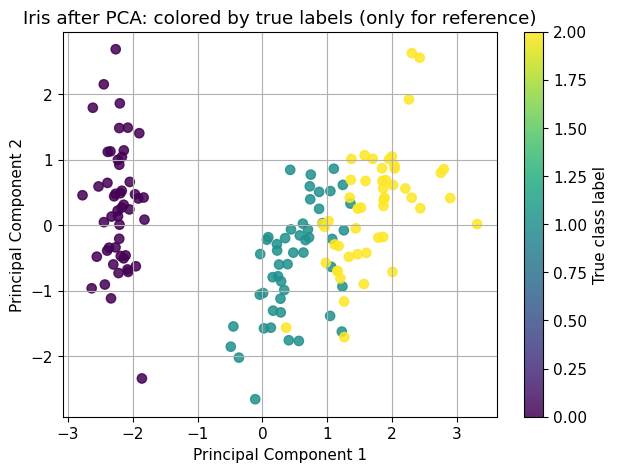

In [15]:
# PCA 降维到二维，方便画图
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print("PCA result shape:", X_pca.shape)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap="viridis", s=45, alpha=0.85)
plt.title("Iris after PCA: colored by true labels (only for reference)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="True class label")
plt.show()

## 在 PCA 二维空间中观察 K-means 每一轮迭代

下面我们用刚才手写的 K-means，在 PCA 后的二维数据上运行。

这样做的主要原因：

- 二维空间容易画图。
- 可以看到每一轮样本如何被重新分配。
- 可以看到聚类中心如何移动。

我们设置：

```python
K = 3
max_iter = 10
```

因为 Iris 真实类别有 3 类，所以先尝试 K=3。

In [34]:
# 在 PCA 二维空间上运行手写 K-means，保存每一轮过程
labels_iris_manual, centers_iris_manual, history_iris = kmeans_manual(
    X_pca,
    K=3,
    max_iter=10,
    random_state=8
)

print("Saved iterations:", len(history_iris))
print("Final centers in PCA space:")
print(np.round(centers_iris_manual, 3))

Saved iterations: 8
Final centers in PCA space:
[[-2.216  0.797]
 [ 1.173 -0.066]
 [-1.881 -0.948]]


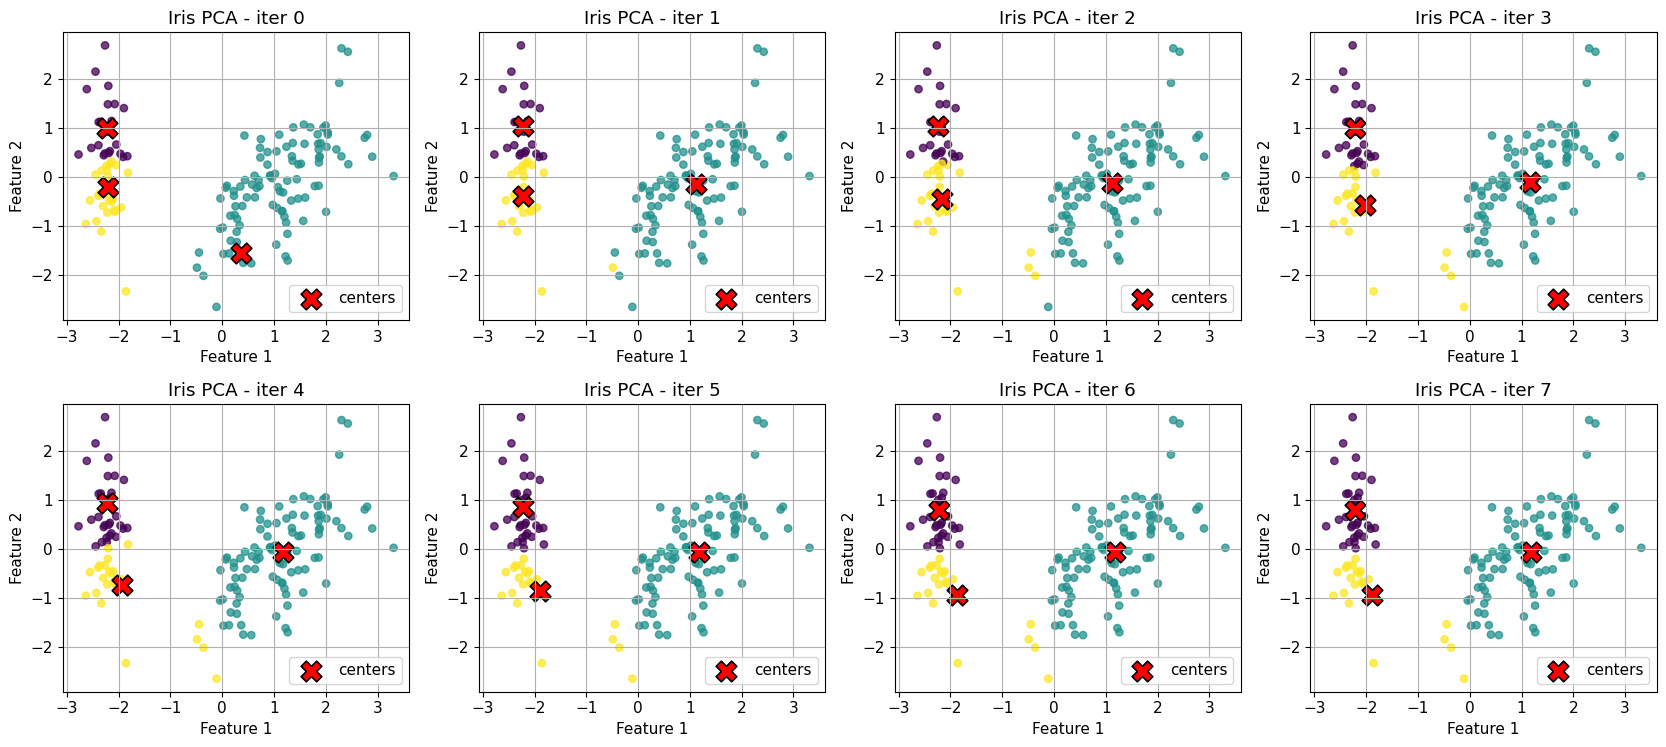

In [35]:
# 画出 Iris 数据中 K-means 每一轮迭代结果
plot_kmeans_history(X_pca, history_iris, title_prefix="Iris PCA - iter")

## 解释上面的每轮迭代图

每张图代表一次迭代状态：

- 点的颜色：K-means 当前分配的簇标签。
- 红色 X：当前聚类中心。
- 每一轮之后，中心会根据簇内样本平均位置重新移动。

观察重点：

1. 初始时中心可能比较随机。
2. 经过几轮迭代后，样本分组变得稳定。
3. center 最后通常会停在每个数据团的中间位置。

---

## 为什么有些类别可能混在一起？

Iris 的 setosa 通常很好分。  
但 versicolor 和 virginica 在特征空间里有一定重叠，所以 K-means 可能无法完全区分它们。

这不是代码错了，而是数据本身存在重叠。

## 使用 scikit-learn 的 KMeans

手写 K-means 适合教学理解。  
实际项目中通常直接使用 scikit-learn：

```python
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3)
model.fit(X)
labels = model.labels_
centers = model.cluster_centers_
```

下面我们在**标准化后的 4 维 Iris 特征**上训练 K-means。  
然后把中心点通过 PCA 转换到二维空间中进行可视化。

In [18]:
# 在标准化后的 4 维特征上训练 K-means
kmeans_iris = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=RANDOM_STATE
)

kmeans_iris.fit(X_scaled)

labels_iris = kmeans_iris.labels_
centers_scaled = kmeans_iris.cluster_centers_

# 为了在 PCA 图上画中心点，需要把 4 维中心点转换到 PCA 的二维空间
centers_pca = pca.transform(centers_scaled)

print("Cluster labels for first 20 samples:")
print(labels_iris[:20])

print("\nCluster centers in standardized 4D feature space:")
display(pd.DataFrame(centers_scaled, columns=X_iris.columns).round(3))

print("\nInertia / SSE:", round(kmeans_iris.inertia_, 3))
print("Davies-Bouldin Index:", round(davies_bouldin_score(X_scaled, labels_iris), 3))
print("Silhouette Score:", round(silhouette_score(X_scaled, labels_iris), 3))
print("Adjusted Rand Index against true labels:", round(adjusted_rand_score(y_iris, labels_iris), 3))

Cluster labels for first 20 samples:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Cluster centers in standardized 4D feature space:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.050,-0.883,0.348,0.282
1,-1.015,0.853,-1.305,-1.255
2,1.136,0.088,0.996,1.018



Inertia / SSE: 139.82
Davies-Bouldin Index: 0.834
Silhouette Score: 0.46
Adjusted Rand Index against true labels: 0.62


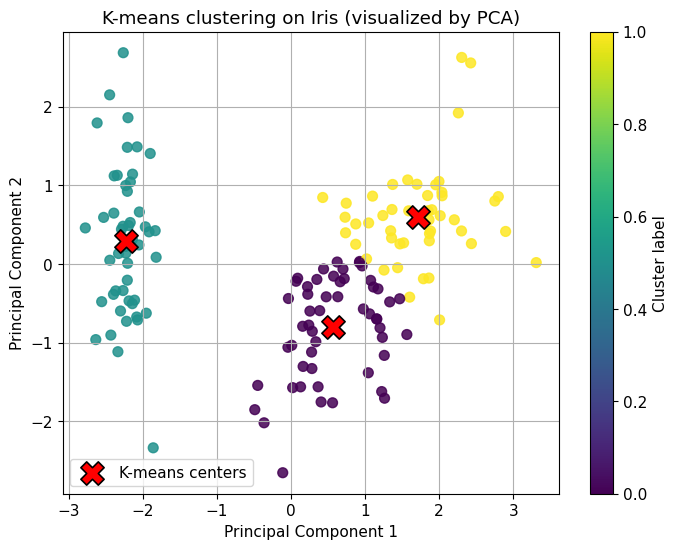

In [19]:
# 可视化 K-means 在 Iris 上的最终聚类结果
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_iris, cmap="viridis", s=50, alpha=0.85)
plt.scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c="red", marker="X", s=280,
    edgecolor="black", linewidth=1.2,
    label="K-means centers"
)
plt.title("K-means clustering on Iris (visualized by PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.colorbar(label="Cluster label")
plt.show()

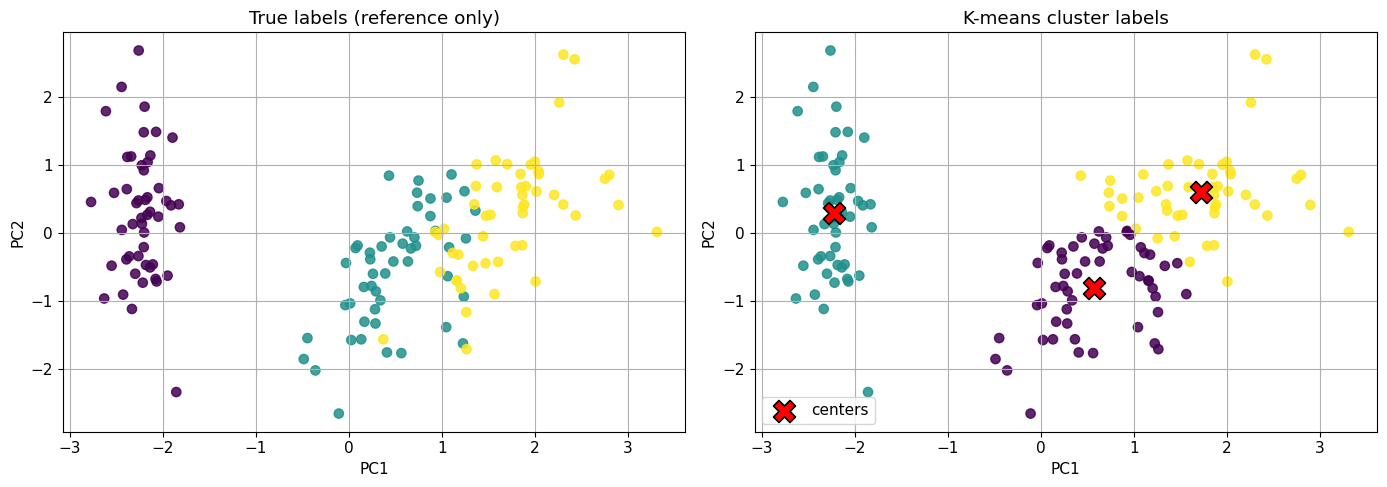

In [20]:
# 对比真实标签和 K-means 聚类标签
# 注意：真实标签只用于对比，不参与 K-means 训练。
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap="viridis", s=45, alpha=0.85)
axes[0].set_title("True labels (reference only)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_iris, cmap="viridis", s=45, alpha=0.85)
axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    c="red", marker="X", s=250,
    edgecolor="black", linewidth=1.2,
    label="centers"
)
axes[1].set_title("K-means cluster labels")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend()

plt.tight_layout()
plt.show()

## 结果怎么解读？

从图中可以看到：

- 有一类花通常非常容易被分出来。
- 另外两类花在 PCA 平面上有部分重叠，所以 K-means 可能会有混淆。
- K-means 不知道真实类别名称，它只根据距离把样本分成 3 组。

---

## 为什么聚类标签和真实标签编号不一致？

K-means 输出的标签只是编号，例如 `0, 1, 2`。  
这些编号没有固定含义。

也就是说：

- K-means 的 cluster 0 不一定等于真实 setosa。
- K-means 的 cluster 1 不一定等于真实 versicolor。
- K-means 的 cluster 2 不一定等于真实 virginica。

如果要和真实类别比较，更推荐使用 ARI 这样的指标，而不是直接比较标签编号是否相同。

# 📖 1.3 Explore K-means with different parameters（K, iters, DBI）

## 什么是 DBI？

DBI 的英文全称是：

> Davies-Bouldin Index

它是一种聚类内部评估指标。  
它不需要真实标签，只根据聚类结果本身评估效果。

DBI 关注两个方面：

1. **簇内紧凑性**：同一个簇内部的点是否靠得近？
2. **簇间分离度**：不同簇之间是否离得远？

通俗理解：

> 好的聚类应该是：每个簇内部很紧密，不同簇之间距离很远。

---

## DBI 越大越好还是越小越好？

DBI 是：

> **越小越好。**

但要注意：DBI 只是一个参考指标。  
真实任务中还需要结合业务意义、可解释性、可视化结果一起判断。

In [21]:
# 先写一个函数：给定 K 和 max_iter，训练 K-means 并返回评估结果

def evaluate_kmeans(X, K, max_iter=300, init="k-means++", n_init=10, random_state=42):
    """
    训练 K-means 并返回常用指标。

    注意：
    DBI 越小越好。
    Inertia 越小通常说明簇内更紧凑，但 K 增大时它几乎一定会下降，所以不能单独看。
    Silhouette 越大通常越好，范围大约在 [-1, 1]。
    """
    model = KMeans(
        n_clusters=K,
        init=init,
        n_init=n_init,
        max_iter=max_iter,
        random_state=random_state
    )

    # 限制底层数学库线程数，避免部分教学电脑或在线环境运行过慢。
    with threadpool_limits(limits=1):
        labels = model.fit_predict(X)

    dbi = davies_bouldin_score(X, labels)
    inertia = model.inertia_
    sil = silhouette_score(X, labels)

    return {
        "K": K,
        "max_iter": max_iter,
        "init": init,
        "n_init": n_init,
        "inertia": inertia,
        "DBI": dbi,
        "silhouette": sil,
        "n_iter_used": model.n_iter_
    }

print("Evaluation function is ready!")

Evaluation function is ready!


## 实验 A：改变 K，观察 DBI 和 Inertia

我们先固定其他参数，只改变 K。

尝试：

```python
K = 2, 3, 4, ..., 10
```

然后记录：

- Inertia：簇内平方距离和，越小越紧凑。
- DBI：越小越好。
- Silhouette：越大越好。

注意：

- Inertia 会随着 K 增加而下降，因为簇越多，每个点离中心通常越近。
- 所以不能只说 Inertia 最小的 K 最好。
- DBI 和 Silhouette 通常更适合帮助判断 K。

In [22]:
results_K = []

for K in range(2, 11):
    result = evaluate_kmeans(
        X_scaled,
        K=K,
        max_iter=300,
        init="k-means++",
        n_init=10,
        random_state=RANDOM_STATE
    )
    results_K.append(result)

results_K_df = pd.DataFrame(results_K)

print("K-means results for different K values:")
display(results_K_df.round(4))

best_k_by_dbi = results_K_df.loc[results_K_df["DBI"].idxmin(), "K"]
best_k_by_sil = results_K_df.loc[results_K_df["silhouette"].idxmax(), "K"]

print(f"Best K by DBI        : {best_k_by_dbi}")
print(f"Best K by Silhouette : {best_k_by_sil}")

K-means results for different K values:


,K,max_iter,init,n_init,inertia,DBI,silhouette,n_iter_used
0,2,300,k-means++,10,222.3617,0.5933,0.5818,7
1,3,300,k-means++,10,139.8205,0.8336,0.4599,4
2,4,300,k-means++,10,114.0925,0.8698,0.3869,4
3,5,300,k-means++,10,90.9275,0.9483,0.3459,8
4,6,300,k-means++,10,81.5444,1.0537,0.3171,6
5,7,300,k-means++,10,72.6311,0.9905,0.3202,6
6,8,300,k-means++,10,62.5406,0.9150,0.3387,11
7,9,300,k-means++,10,55.1195,0.9032,0.3424,4
8,10,300,k-means++,10,47.3910,0.8748,0.3518,12


Best K by DBI        : 2
Best K by Silhouette : 2


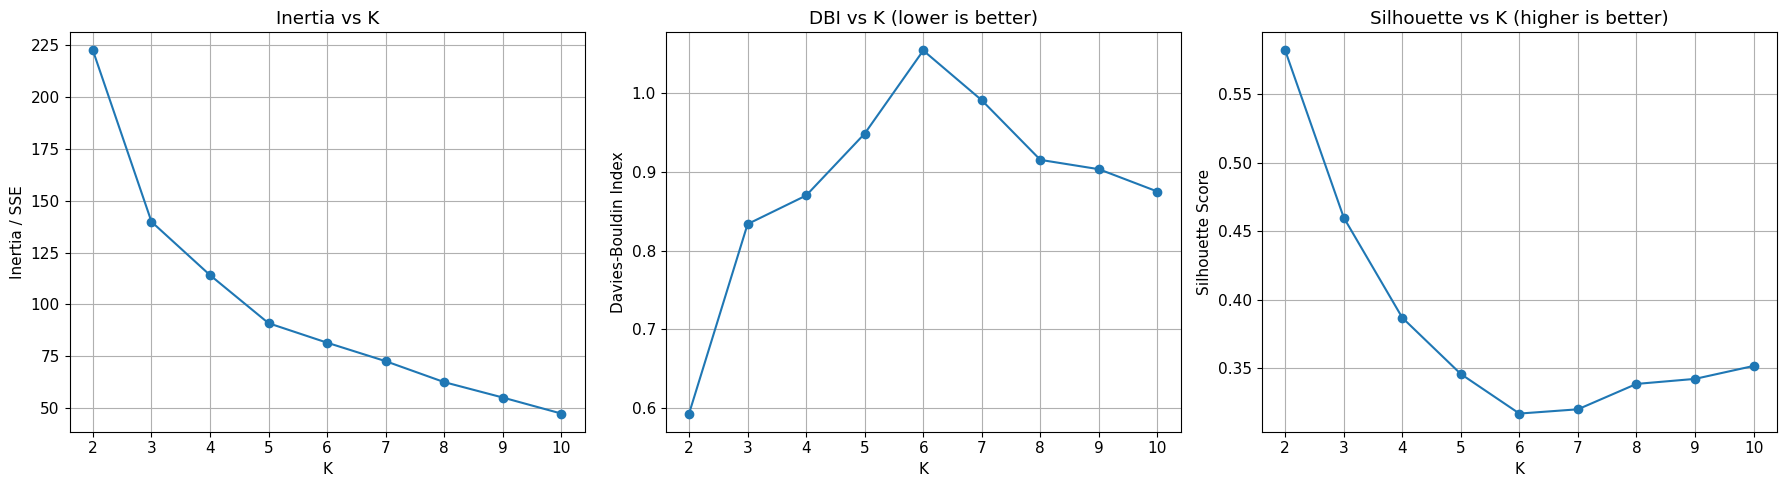

In [23]:
# 画出 K 和指标之间的关系
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_K_df["K"], results_K_df["inertia"], marker="o")
axes[0].set_title("Inertia vs K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia / SSE")

axes[1].plot(results_K_df["K"], results_K_df["DBI"], marker="o")
axes[1].set_title("DBI vs K (lower is better)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Davies-Bouldin Index")

axes[2].plot(results_K_df["K"], results_K_df["silhouette"], marker="o")
axes[2].set_title("Silhouette vs K (higher is better)")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

##### Inertia 也叫 SSE
表示：每个样本点到自己所属聚类中心的距离平方和。
简单理解：
Inertia 越小，说明每个点离自己的中心越近，簇内部越紧密。
##### DBI 是 Davies-Bouldin Index
它衡量的是：
簇内是否紧密，簇间是否分开。
DBI 越低越好。
##### Silhouette Score 叫 轮廓系数。
它衡量的是：一个样本是否更接近自己所在的簇，而远离其他簇。
它的取值范围大致是：
-1 到 1
越接近 1，说明聚类越好。

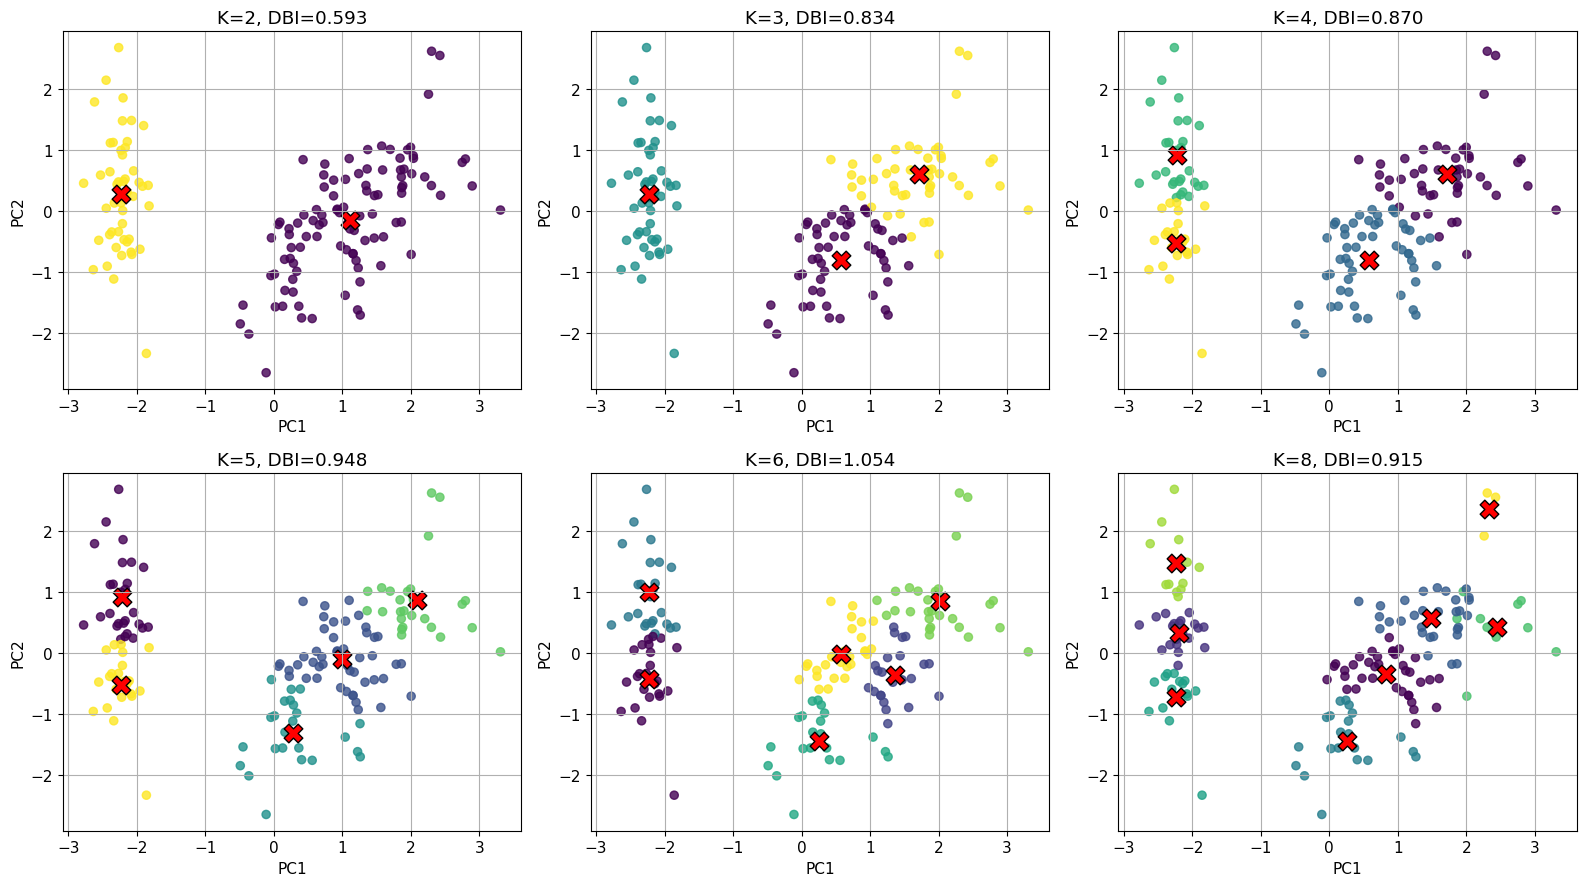

In [24]:
# 对不同 K 的聚类结果进行可视化
K_values_to_plot = [2, 3, 4, 5, 6, 8]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.reshape(-1)

for ax, K in zip(axes, K_values_to_plot):
    model = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_scaled)
    centers_pca_tmp = pca.transform(model.cluster_centers_)
    dbi_tmp = davies_bouldin_score(X_scaled, labels)

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=35, alpha=0.8)
    ax.scatter(
        centers_pca_tmp[:, 0], centers_pca_tmp[:, 1],
        c="red", marker="X", s=180,
        edgecolor="black", linewidth=1.0
    )
    ax.set_title(f"K={K}, DBI={dbi_tmp:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 实验 A 小结

观察不同 K 的图像时，请思考：

1. K 太小时会发生什么？
   - 多个自然簇可能被硬合并。

2. K 太大时会发生什么？
   - 一个自然簇可能被切成多个小簇。

3. 为什么 K=3 不一定在所有指标上都是最优？
   - 因为指标关注的是几何结构，不知道真实类别语义。
   - Iris 的真实类别是 3 类，但数据在特征空间中的几何结构不一定完美对应 3 个球状簇。

---

## 注意

在无监督学习中，选择 K 没有唯一答案。  
通常需要结合：

- 指标，例如 DBI、Silhouette、Inertia elbow
- 可视化结果
- 领域知识
- 业务需求

## 实验 B：改变迭代次数 max_iter / iters

K-means 是迭代算法。  
如果迭代次数太少，中心可能还没稳定。

下面固定 `K=3`，改变最大迭代次数：

```python
max_iter = 1, 2, 3, 5, 10, 20, 50, 100
```

观察 DBI、Inertia 和实际使用迭代轮数 `n_iter_used`。

为了更明显地看到迭代次数影响，这里设置：

```python
n_init = 1
init = "random"
```

这样可以减少多次初始化带来的稳定化效果，让学生更容易观察“迭代不充分”的影响。

In [25]:
iter_values = [1, 2, 3, 5, 10, 20, 50, 100]
results_iter = []

for max_iter in iter_values:
    result = evaluate_kmeans(
        X_scaled,
        K=3,
        max_iter=max_iter,
        init="random",
        n_init=1,
        random_state=RANDOM_STATE
    )
    results_iter.append(result)

results_iter_df = pd.DataFrame(results_iter)

print("K=3 with different max_iter values:")
display(results_iter_df.round(4))

K=3 with different max_iter values:


,K,max_iter,init,n_init,inertia,DBI,silhouette,n_iter_used
0,3,1,random,1,257.0120,0.8204,0.4496,1
1,3,2,random,1,142.1675,0.8287,0.4646,2
2,3,3,random,1,140.3604,0.8314,0.4637,3
3,3,5,random,1,140.0328,0.8324,0.4630,5
4,3,10,random,1,140.0328,0.8324,0.4630,6
5,3,20,random,1,140.0328,0.8324,0.4630,6
6,3,50,random,1,140.0328,0.8324,0.4630,6
7,3,100,random,1,140.0328,0.8324,0.4630,6


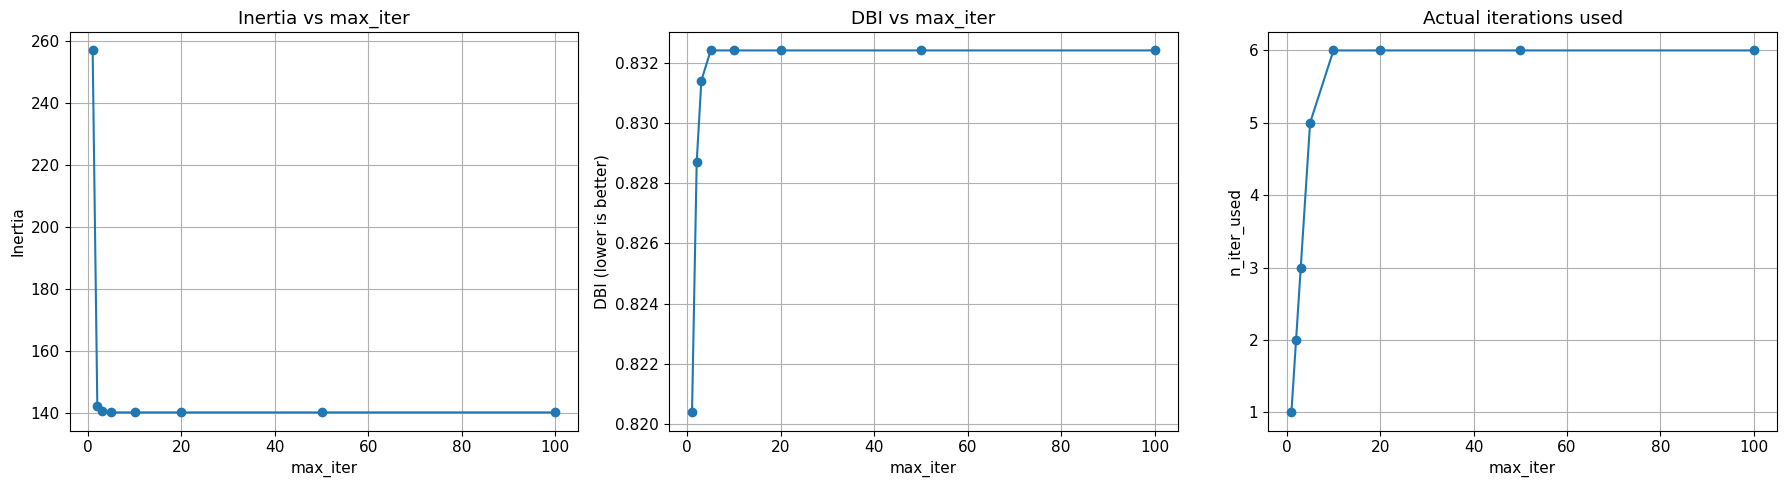

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(results_iter_df["max_iter"], results_iter_df["inertia"], marker="o")
axes[0].set_title("Inertia vs max_iter")
axes[0].set_xlabel("max_iter")
axes[0].set_ylabel("Inertia")

axes[1].plot(results_iter_df["max_iter"], results_iter_df["DBI"], marker="o")
axes[1].set_title("DBI vs max_iter")
axes[1].set_xlabel("max_iter")
axes[1].set_ylabel("DBI (lower is better)")

axes[2].plot(results_iter_df["max_iter"], results_iter_df["n_iter_used"], marker="o")
axes[2].set_title("Actual iterations used")
axes[2].set_xlabel("max_iter")
axes[2].set_ylabel("n_iter_used")

plt.tight_layout()
plt.show()

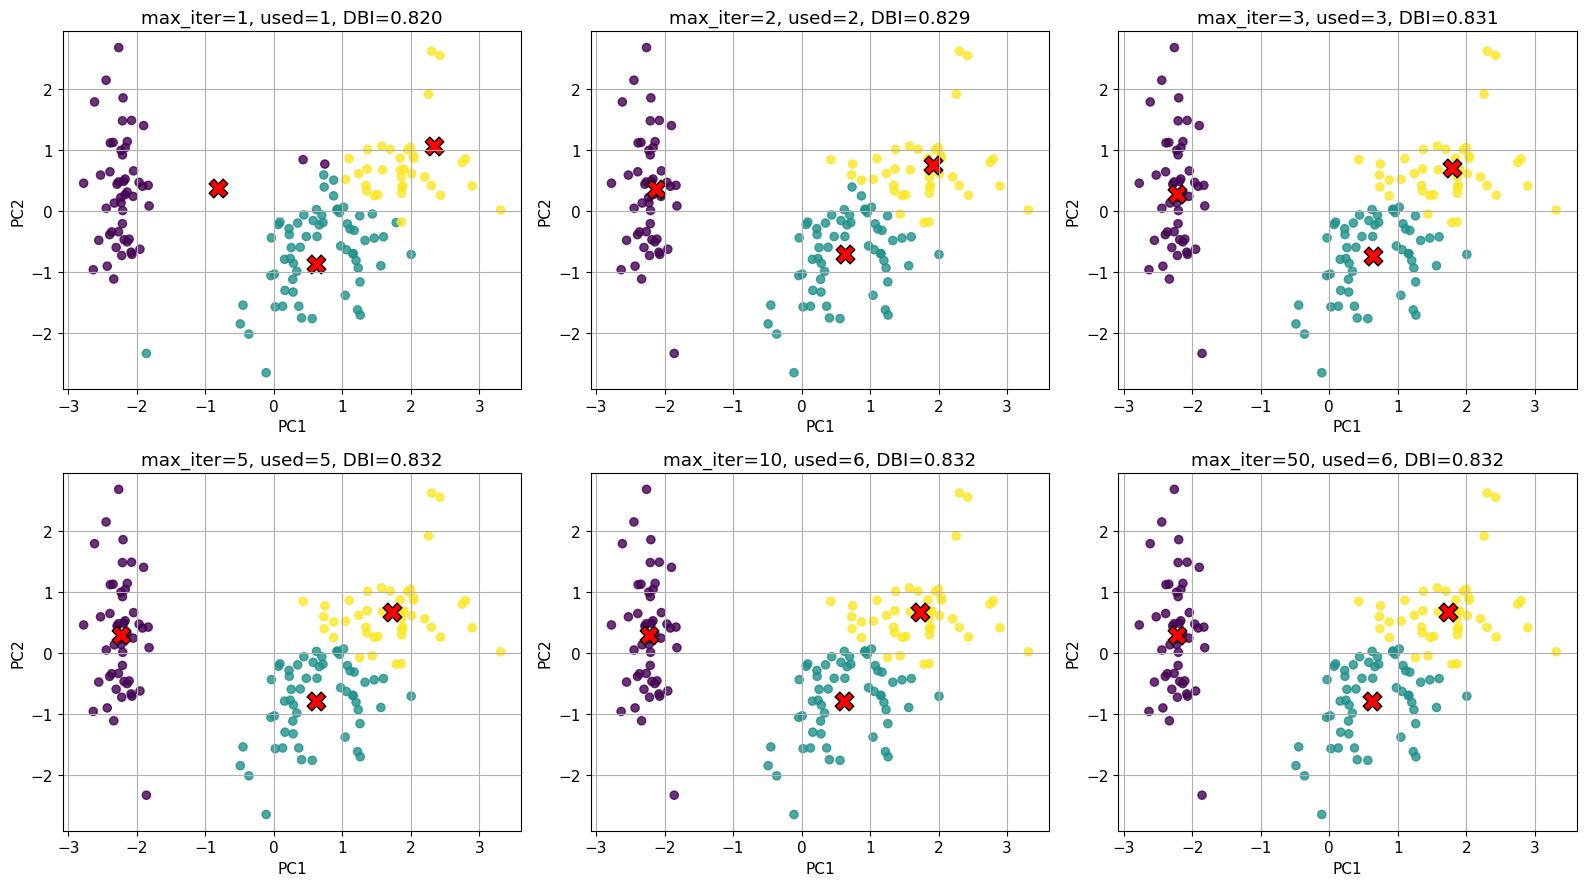

In [27]:
# 可视化不同 max_iter 下的聚类结果
max_iter_values_to_plot = [1, 2, 3, 5, 10, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.reshape(-1)

for ax, max_iter in zip(axes, max_iter_values_to_plot):
    model = KMeans(
        n_clusters=3,
        init="random",
        n_init=1,
        max_iter=max_iter,
        random_state=RANDOM_STATE
    )
    labels = model.fit_predict(X_scaled)
    centers_pca_tmp = pca.transform(model.cluster_centers_)
    dbi_tmp = davies_bouldin_score(X_scaled, labels)

    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="viridis", s=35, alpha=0.8)
    ax.scatter(
        centers_pca_tmp[:, 0], centers_pca_tmp[:, 1],
        c="red", marker="X", s=180,
        edgecolor="black", linewidth=1.0
    )
    ax.set_title(f"max_iter={max_iter}, used={model.n_iter_}, DBI={dbi_tmp:.3f}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()

## 实验 B 小结

观察结果时可以注意：

- 当 `max_iter` 很小时，K-means 可能还没有完全收敛。
- 当 `max_iter` 足够大时，实际使用迭代数 `n_iter_used` 可能不会继续增加，因为算法已经提前收敛。
- 实际项目中通常不需要把 `max_iter` 设置得特别大，默认值常常足够。

---

## 什么是“收敛”？

在 K-means 中，收敛通常表示：

- 中心点几乎不再移动，或者
- 样本的簇分配不再变化，或者
- 达到最大迭代次数。

直观理解：

> 算法已经找到了一个相对稳定的分组方案。

## 实验 C：K 和迭代次数的组合影响（DBI heatmap）

接下来做一个二维参数实验：

- 横轴：不同 K
- 纵轴：不同 max_iter
- 单元格颜色：DBI 分数

这样学生可以看到：

- K 对结果影响很明显。
- max_iter 太小时可能影响结果。
- 当迭代次数足够后，继续增大 max_iter 影响可能变小。

In [28]:
K_grid = list(range(2, 9))
iter_grid = [1, 2, 3, 5, 10, 20, 50]

heatmap_values = np.zeros((len(iter_grid), len(K_grid)))

for i, max_iter in enumerate(iter_grid):
    for j, K in enumerate(K_grid):
        result = evaluate_kmeans(
            X_scaled,
            K=K,
            max_iter=max_iter,
            init="random",
            n_init=1,
            random_state=RANDOM_STATE
        )
        heatmap_values[i, j] = result["DBI"]

heatmap_df = pd.DataFrame(heatmap_values, index=iter_grid, columns=K_grid)
print("DBI heatmap table: rows=max_iter, columns=K")
display(heatmap_df.round(3))

DBI heatmap table: rows=max_iter, columns=K


,2,3,4,5,6,7,8
1,0.973,0.820,1.272,1.206,1.159,1.175,1.056
2,0.593,0.829,0.902,1.179,1.155,1.173,1.054
3,0.593,0.831,0.873,1.154,1.142,1.164,1.045
5,0.593,0.832,0.878,1.147,1.114,1.162,1.039
10,0.593,0.832,0.879,1.055,1.051,1.162,1.039
20,0.593,0.832,0.879,1.055,1.051,1.162,1.039
50,0.593,0.832,0.879,1.055,1.051,1.162,1.039


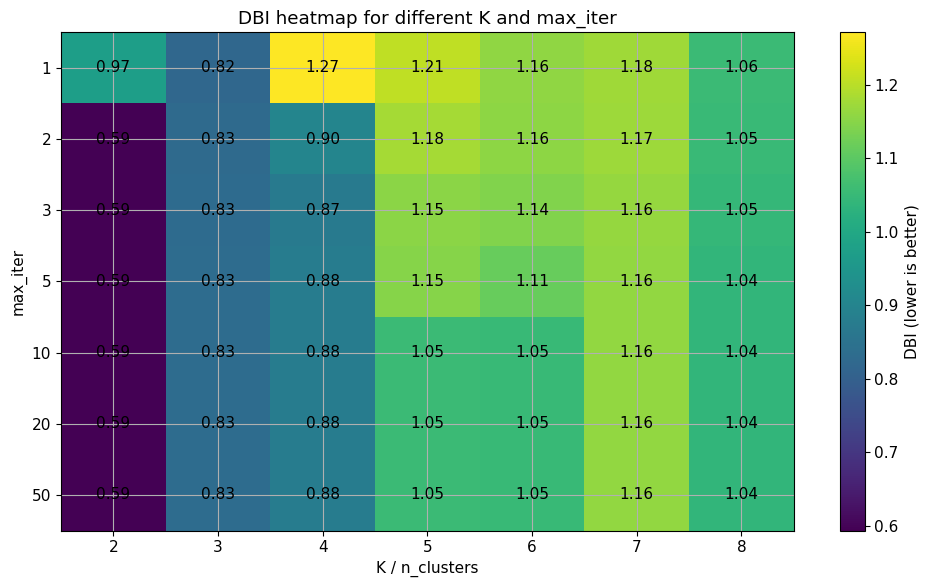

In [29]:
plt.figure(figsize=(10, 6))
im = plt.imshow(heatmap_values, aspect="auto")
plt.colorbar(im, label="DBI (lower is better)")

plt.xticks(ticks=np.arange(len(K_grid)), labels=K_grid)
plt.yticks(ticks=np.arange(len(iter_grid)), labels=iter_grid)
plt.xlabel("K / n_clusters")
plt.ylabel("max_iter")
plt.title("DBI heatmap for different K and max_iter")

# 在每个格子里写上 DBI 数值，方便教学观察
for i in range(len(iter_grid)):
    for j in range(len(K_grid)):
        plt.text(j, i, f"{heatmap_values[i, j]:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()

这张热力图说明：在当前实验中，K=2 的 DBI 最低，聚类结构最清晰；max_iter 增大后结果逐渐稳定，通常不需要特别大的迭代次数。

## 实验 D：初始化方法 init 的影响

K-means 的结果会受初始中心影响。

下面比较两种初始化方法：

- `random`
- `k-means++`

通常：

- `random` 简单，但可能不稳定。
- `k-means++` 的思想是：

初始中心不要全都挤在一起，而是尽量分散地选。

也就是说，它希望一开始选出来的中心点大概覆盖数据的不同区域。

这样后面 K-means 迭代时会更稳定。

In [30]:
init_results = []

for init_method in ["random", "k-means++"]:
    for seed in range(10):
        result = evaluate_kmeans(
            X_scaled,
            K=3,
            max_iter=300,
            init=init_method,
            n_init=1,
            random_state=seed
        )
        result["seed"] = seed
        init_results.append(result)

init_results_df = pd.DataFrame(init_results)

print("Different initialization methods across random seeds:")
display(init_results_df[["init", "seed", "inertia", "DBI", "silhouette", "n_iter_used"]].round(4))

summary_init = init_results_df.groupby("init")[["inertia", "DBI", "silhouette", "n_iter_used"]].agg(["mean", "std"])
print("\nSummary by init method:")
display(summary_init.round(4))

Different initialization methods across random seeds:


,init,seed,inertia,DBI,silhouette,n_iter_used
0,random,0,140.9015,0.8275,0.4565,4
1,random,1,140.9015,0.8275,0.4565,6
2,random,2,140.0820,0.8323,0.4566,4
3,random,3,140.9015,0.8275,0.4565,7
4,random,4,140.9015,0.8275,0.4565,5
5,random,5,191.0247,0.7894,0.4799,7
6,random,6,139.8205,0.8336,0.4599,7
7,random,7,140.0820,0.8323,0.4566,6
8,random,8,140.0328,0.8324,0.4630,11
9,random,9,140.0328,0.8324,0.4630,3



Summary by init method:


inertia              DBI         silhouette         n_iter_used  \
               mean      std    mean     std       mean     std        mean   
init                                                                          
k-means++  145.4419  16.0233  0.8264  0.0133     0.4609  0.0072         5.6   
random     145.4681  16.0133  0.8262  0.0132     0.4605  0.0073         6.0   

                   
              std  
init               
k-means++  1.8379  
random     2.2608

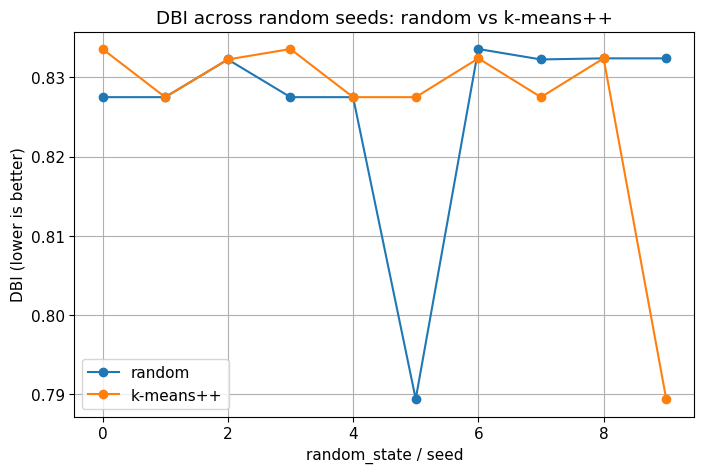

In [31]:
plt.figure(figsize=(8, 5))

for init_method in ["random", "k-means++"]:
    subset = init_results_df[init_results_df["init"] == init_method]
    plt.plot(subset["seed"], subset["DBI"], marker="o", label=init_method)

plt.title("DBI across random seeds: random vs k-means++")
plt.xlabel("random_state / seed")
plt.ylabel("DBI (lower is better)")
plt.legend()
plt.show()

随机种子 seed = 0 ~ 9 分别运行 K-means，然后观察 DBI、Inertia、Silhouette 和迭代次数的变化
本实验比较了 random 初始化和 k-means++ 初始化在不同 random_state 下的聚类表现。  
结果显示，两种初始化方式在 Iris 数据集上的平均 DBI、Inertia 和 Silhouette 差异都很小，说明在该数据集上初始化方式对最终聚类质量影响不大。  
不过，k-means++ 的平均迭代次数略低，说明其收敛效率略优。  
此外，不同随机种子会导致 K-means 收敛到不同的局部结果，因此实际使用中通常建议设置 random_state 保证实验可复现，并使用 k-means++ 或多次初始化来提高稳定性。  

## 拓展：K-means 不适合什么数据？

K-means 假设簇大致是“球状”的。  
如果数据呈现月牙形、环形，K-means 可能效果很差。

下面用 `make_moons` 生成一个月牙形数据，观察 K-means 的局限性。

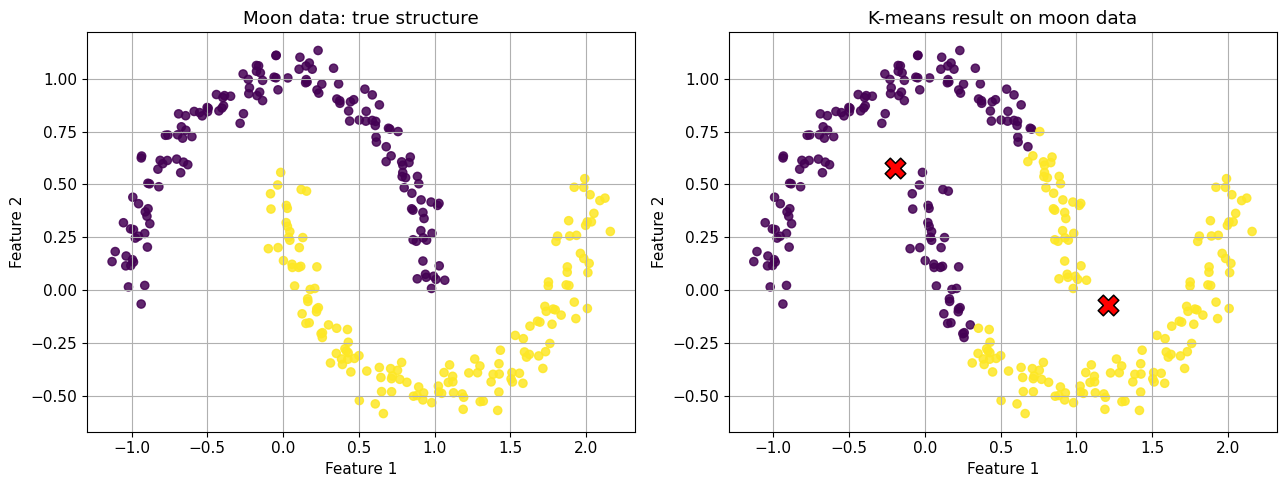

DBI on moon data: 0.78
ARI against moon true structure: 0.247


In [32]:
X_moon, y_moon = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)

model_moon = KMeans(n_clusters=2, init="k-means++", n_init=10, random_state=RANDOM_STATE)
labels_moon = model_moon.fit_predict(X_moon)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap="viridis", s=35, alpha=0.85)
axes[0].set_title("Moon data: true structure")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=labels_moon, cmap="viridis", s=35, alpha=0.85)
axes[1].scatter(
    model_moon.cluster_centers_[:, 0], model_moon.cluster_centers_[:, 1],
    c="red", marker="X", s=220,
    edgecolor="black", linewidth=1.1
)
axes[1].set_title("K-means result on moon data")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

print("DBI on moon data:", round(davies_bouldin_score(X_moon, labels_moon), 3))
print("ARI against moon true structure:", round(adjusted_rand_score(y_moon, labels_moon), 3))

## 月牙数据说明了什么？

K-means 更擅长处理：

- 团状
- 球状
- 凸形
- 大致均匀分布的簇

对于月牙形、环形、密度变化明显的数据，可以考虑其他聚类方法，例如：

- DBSCAN
- Spectral Clustering
- Agglomerative Clustering

这部分不是本实验重点，但可以作为课堂拓展。

# ✅ 本实验总结

## 核心概念

### 1. K-means 是什么？

K-means 是一种无监督聚类算法。  
它通过不断更新中心点，把样本分成 K 个簇。

---

### 2. K-means 每轮做什么？

每一轮包含两步：

1. 分配样本到最近中心。
2. 根据簇内样本平均值更新中心。

---

### 3. 为什么需要标准化？

因为 K-means 基于距离。  
不同特征尺度差异过大，会影响距离计算。

---

### 4. 为什么使用 PCA？

PCA 主要用于可视化。  
它把高维数据压缩到二维，让我们能画出散点图。

---

### 5. DBI 如何理解？

DBI 评价聚类效果：

- 簇内越紧凑越好。
- 簇间越分离越好。
- DBI 越小越好。

---

### 6. 参数怎么影响结果？

- `K` 决定分成几个簇，是最重要参数。
- `max_iter` 太小可能导致未收敛。
- `init` 会影响初始中心，进而影响最终结果。
- `n_init` 可以通过多次运行提高稳定性。

---

## 总结：

> 本实验使用 Iris 数据集进行 K-means 聚类。首先对原始特征进行标准化，然后使用 PCA 将数据降到二维空间进行可视化。通过手写 K-means 过程，我们观察到算法会不断重复“样本分配”和“中心更新”两个步骤，直到中心趋于稳定。随后使用 scikit-learn 的 KMeans 对标准化后的 Iris 数据进行聚类，并通过 PCA 图展示最终聚类结果。最后，我们改变聚类数量 K、最大迭代次数 max_iter 和初始化方法 init，并使用 DBI 指标评估不同参数组合下的聚类效果。实验表明，K 的选择对聚类结果影响最大，而适当增加 max_iter 和使用 k-means++ 初始化可以提高算法稳定性。

# 🧠 课堂思考题

请学生尝试回答以下问题：

1. K-means 为什么需要提前指定 K？
2. 如果 K 设置得太小，会出现什么问题？
3. 如果 K 设置得太大，会出现什么问题？
4. 为什么 K-means 前通常要做标准化？
5. PCA 在本实验中主要起什么作用？
6. DBI 越大越好还是越小越好？为什么？
7. 为什么 K-means 的 cluster label 不能直接等同于真实类别 label？
8. K-means 为什么不适合月牙形数据？
9. `random` 初始化和 `k-means++` 初始化有什么区别？
10. 如果你拿到一个真实的无标签客户数据集，你会如何选择 K？

---

# 🧩 课后练习

下面是建议学生修改的代码实验：

1. 把 Iris 的 `K=3` 改成 `K=2`、`K=4`、`K=5`，观察图像变化。
2. 把 `max_iter=1`，观察结果是否稳定。
3. 把 `init="k-means++"` 改成 `init="random"`，多换几个 `random_state`。
4. 尝试只用 Iris 的两个原始特征做 K-means，例如 petal length 和 petal width。
5. 尝试使用 `StandardScaler` 前后的结果对比，看看是否有明显变化。
6. 进一步了解 `DBSCAN`，看看它在 moon data 上是否比 K-means 更合适。

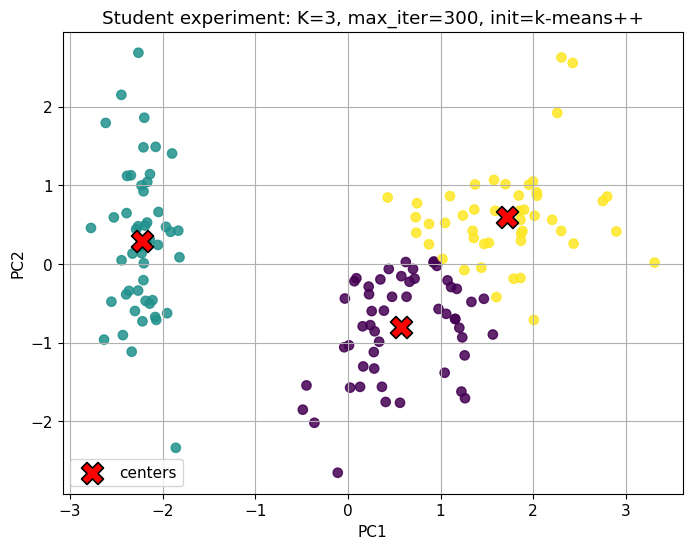

DBI: 0.834 (lower is better)
Silhouette: 0.46 (higher is better)
Iterations used: 4


In [33]:
# 课后练习模板：学生可以在这里自由修改参数
# 例如：K=2, 3, 4, 5; max_iter=1, 2, 10, 100; init="random" 或 "k-means++"

student_K = 3
student_max_iter = 300
student_init = "k-means++"
student_random_state = 42

student_model = KMeans(
    n_clusters=student_K,
    max_iter=student_max_iter,
    init=student_init,
    n_init=10,
    random_state=student_random_state
)

student_labels = student_model.fit_predict(X_scaled)
student_centers_pca = pca.transform(student_model.cluster_centers_)
student_dbi = davies_bouldin_score(X_scaled, student_labels)
student_sil = silhouette_score(X_scaled, student_labels)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=student_labels, cmap="viridis", s=45, alpha=0.85)
plt.scatter(
    student_centers_pca[:, 0], student_centers_pca[:, 1],
    c="red", marker="X", s=250,
    edgecolor="black", linewidth=1.2,
    label="centers"
)
plt.title(f"Student experiment: K={student_K}, max_iter={student_max_iter}, init={student_init}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

print("DBI:", round(student_dbi, 3), "(lower is better)")
print("Silhouette:", round(student_sil, 3), "(higher is better)")
print("Iterations used:", student_model.n_iter_)